In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, roc_curve
)
from imblearn.over_sampling import SMOTE
print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
url = "https://raw.githubusercontent.com/nsethi31/Kaggle-Data-Credit-Card-Fraud-Detection/master/creditcard.csv"
print("Downloading dataset")
df = pd.read_csv(url)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(f"Total transactions: {df.shape[0]:,}")
print(f"Total features:    {df.shape[1]}")
print(f"Missing values:   {df.isnull().sum().sum()}")
print(f"Duplicate rows:    {df.duplicated().sum()}")
df = df.drop_duplicates().reset_index(drop=True)
print(f"After removing duplicates: {len(df):,} transactions")
print(f"--- Class Distribution ---")
print(f"Legit (0):  {(df['Class']==0).sum():,}")
print(f"Fraud (1):  {(df['Class']==1).sum():,}")
print(f"Fraud %:    {df['Class'].mean()*100:.3f}%")

Total transactions: 284,807
Total features:    31
Missing values:   0
Duplicate rows:    1081
After removing duplicates: 283,726 transactions
--- Class Distribution ---
Legit (0):  283,253
Fraud (1):  473
Fraud %:    0.167%


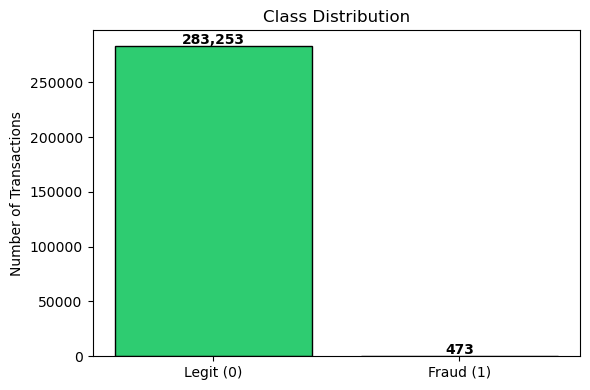

In [5]:
plt.figure(figsize=(6, 4))
counts = df["Class"].value_counts()
plt.bar(["Legit (0)", "Fraud (1)"], counts, color=["#2ecc71", "#e74c3c"], edgecolor="black")
plt.title("Class Distribution")
plt.ylabel("Number of Transactions")
for i, (label, count) in enumerate(zip(["Legit (0)", "Fraud (1)"], counts)):
    plt.text(i, count + 2000, f"{count:,}", ha="center", fontweight="bold")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

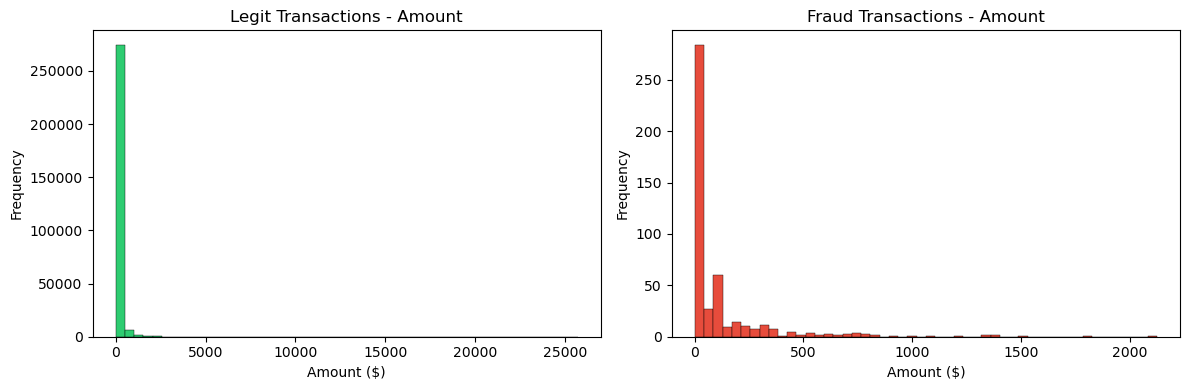

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df[df["Class"]==0]["Amount"], bins=50, color="#2ecc71", edgecolor="black", linewidth=0.3)
axes[0].set_title("Legit Transactions - Amount")
axes[0].set_xlabel("Amount ($)")
axes[0].set_ylabel("Frequency")
axes[1].hist(df[df["Class"]==1]["Amount"], bins=50, color="#e74c3c", edgecolor="black", linewidth=0.3)
axes[1].set_title("Fraud Transactions - Amount")
axes[1].set_xlabel("Amount ($)")
axes[1].set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("amount_distribution.png", dpi=150)
plt.show()

In [8]:
X = df.drop("Class", axis=1)
y = df["Class"].values
scaler = RobustScaler()
X[["Amount", "Time"]] = scaler.fit_transform(X[["Amount", "Time"]])
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]:,} transactions")
print(f"Testing set:  {X_test.shape[0]:,} transactions")
print(f"Fraud in train: {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Fraud in test:  {y_test.sum()} ({y_test.mean()*100:.3f}%)")

Training set: 226,980 transactions
Testing set:  56,746 transactions
Fraud in train: 378 (0.167%)
Fraud in test:  95 (0.167%)
